# Agent Frameworks - AWS Strands Additional Lab
This code designs a multi-agent orchestration pipeline using the Strands SDK and a local Ollama model [qwen2.5:7b] to generate, translate, selectively save, and format a product tagline. [1] 

## A graph-based **workflow engine** with human-in-the-loop approval
The workflow automates a content creation pipeline with human-in-the-loop validation. It utilizes specialized LLM agents for creative writing and translation, incorporates a manual review checkpoint, handles external tool interop via the Model Context Protocol (MCP) for file operations, and applies brand styling to the final output.

### 1. Architectural Workarounds (FunctionNode)
* SDK Compatibility Hack: Since GraphBuilder.add_node() does not natively accept raw Python functions yet, the code introduces a FunctionNode(MultiAgentBase) adapter wrapper.
* Payload Normalization: Includes helper utilities (_make_agent_result, _extract_text) to transform raw functional text outputs into compliant SDK agent structures (AgentResult), preventing pipeline crashes between dissimilar node components. [2] 

### 2. Sequential Agent Execution
* writer: Processes the initial product context using WriterAgent to create a concise, one-sentence product tagline.
* translator: Automatically consumes the output of the writer and uses TranslatorAgent to translate the text exactly into natural Spanish.

### 3. Human-in-the-Loop & State Management
* interrupter (ask_human): Pauses the workflow to print a translation preview in the console. It queries the user with an interactive input() prompt (y/n).
* Cross-Node State Stashing: Because data might bypass the saving node depending on the user's choice, it stashes the verified translation text inside a shared reference dictionary (invocation_state["saved_text"]) ensuring downstream nodes can access it regardless of the execution path.

### 4. Resilient File I/O via MCP & Fallback
* saver (save_file): Executes conditionally if the user inputs y or yes.
* Hybrid Storage Pattern: It attempts an automated tool write sequence utilizing an MCP Filesystem Client server (@modelcontextprotocol/server-filesystem). If the external protocol client fails or errors out, an explicit try/except block cleanly falls back to standard Python synchronous file writing (open()) in the local workspace/ directory to prevent workflow termination.

### 5. Output Finalization
* formatter (format_output): Pulls the text out of the state repository, forces the entire string into uppercase characters, and wraps it into a stylized *** BRAND OUTPUT *** block layout.

[1] [https://strandsagents.com](https://strandsagents.com/blog/strands-agents-typescript-v1/)
[2] [https://strandsagents.com](https://strandsagents.com/docs/api/python/strands.agent.agent_result/)


### Setup

Following the instructions in the ["Day 2: AWS Strands Lab Notebook"](../../2_strands_pydantic/strands_lab.ipynb).

If you want to see more details on its configuration, take a look at the end section here: ["Appendix - Additional Setup Instructions"](#appendix---additional-setup-instructions)

In [19]:
import re
import asyncio
import os
from typing import Any
from dotenv import load_dotenv
from mcp.client.stdio import stdio_client, StdioServerParameters
from strands import Agent
from strands.agent.agent_result import AgentResult
from strands.models.openai import OpenAIModel
from strands.multiagent import GraphBuilder
from strands.multiagent.base import MultiAgentBase, MultiAgentResult, NodeResult
from strands.multiagent.graph import GraphState
from strands.telemetry.metrics import EventLoopMetrics
from strands.tools.mcp import MCPClient

# Load environment configuration variables
load_dotenv(override=True)

# -------------------------------------------------------------------
# Establish target workspace directory structure for file generation
workspace = os.path.abspath("workspace")
os.makedirs(workspace, exist_ok=True)

# Instantiate the Model Context Protocol (MCP) Filesystem server client
filesystem_mcp = MCPClient(
    lambda: stdio_client(
        StdioServerParameters(
            command="npx",
            args=["-y", "@modelcontextprotocol/server-filesystem", workspace],
            cwd=workspace
        )
    )
)

# -------------------------------------------------------------------
# Configure the local inference server endpoint client mapping to Ollama
ollama_model = OpenAIModel(
    client_args={
        "api_key": "Ollama",
        "base_url": "http://localhost:11434/v1"
    },
    model_id="qwen2.5:7b",
    params={
        "temperature": 0.1,
        "seed": 42,
        "tool_choice": "auto",    # explicit, though it's the default
    },
)

# -------------------------------------------------------------------
# Agent configurations
# Marketing specialist tasked with generation of product copy
writer_agent = Agent(
    model=ollama_model,
    name="WriterAgent",
    system_prompt="You are a professional creative marketer. Write a concise, 1-sentence product tagline. Do not use quotation marks.",
)

# Language translation engine translating input into target format
translator_agent = Agent(
    model=ollama_model,
    name="TranslatorAgent",
    system_prompt="You are an expert translator. Translate the given text exactly into natural Spanish. Return only the final Spanish text.",
)


def _make_agent_result(text: str) -> AgentResult:
    """
    Builds a minimal AgentResult wrapping the provided raw string payload.
    
    This ensures functional node outputs match agent signatures, making them 
    compatible with the graph execution engine's downstream evaluations.
    """
    return AgentResult(
        stop_reason="end_turn",
        message={"role": "assistant", "content": [{"text": text}]},
        metrics=EventLoopMetrics(),
        state={},
    )


def _extract_text(task: Any) -> str:
    """
    Extracts and standardizes data payloads into a plain string.
    
    Handles initial entry inputs (raw string) as well as intermediary content 
    blocks built dynamically by upstream graph nodes (list of dictionaries).
    """
    if isinstance(task, str):
        return task
    if isinstance(task, list):
        return "\n".join(block["text"] for block in task if isinstance(block, dict) and "text" in block)
    return str(task)


def _node_text(state: GraphState, node_id: str) -> str:
    """
    Extracts and flattens text contents generated from a target node execution.
    
    Accesses the completed node inside the active GraphState context and flattens 
    either an AgentResult or multi-agent layout down into an evaluation string.
    """
    node_result = state.results.get(node_id)
    if node_result is None:
        return ""
    return "\n".join(str(r) for r in node_result.get_agent_results()).strip()


class FunctionNode(MultiAgentBase):
    """
    Adapter wrapper converting standard functions into valid MultiAgentBase nodes.
    
    Enables arbitrary, deterministic execution branches to be registered inside 
    the GraphBuilder without creating fully managed AI Agent objects.
    It is the same role our Executor subclasses played in agent_framework.
    
    Note: As of this SDK version, GraphBuilder.add_node() only accepts AgentBase or 
    MultiAgentBase instances - plain functions aren't supported as first-class nodes 
    yet (tracked upstream in strands-agents/sdk-python#544). 
    """
    def __init__(self, fn, node_id: str):
        self.id = node_id
        self._fn = fn

    async def invoke_async(self, task: Any, invocation_state: dict | None = None, **kwargs: Any) -> MultiAgentResult:
        """
        Executes the underlying functional callable within the graph pipeline loop.
        """
        text_in = _extract_text(task)
        state = invocation_state if invocation_state is not None else {}
        if asyncio.iscoroutinefunction(self._fn):
            output_text = await self._fn(text_in, state)
        else:
            output_text = self._fn(text_in, state)
        return MultiAgentResult(results={self.id: NodeResult(result=_make_agent_result(output_text))})


def ask_human(text: str, invocation_state: dict) -> str:
    """
    Prompts human operator via console input to decide if progress is persisted.
    
    Stashes the validated string content inside the shared `invocation_state` 
    reference mapping so it can be extracted in later pipeline steps.
    """
    print(f"\n🔍 [TRANSLATION PREVIEW]:\n{text}")
    invocation_state["saved_text"] = text
    answer = input("💾 Would you like to save this translation to a file? (y/n): ").strip().lower()
    print(f"🔍 DEBUG: received answer = {answer!r}")   # <-- add this
    return answer


def _extract_last_agent_response(text: str) -> str:
    """
    Strips the graph-generated lineage wrapper ('Original Task: ...',
    'Inputs from previous nodes: ...') and returns only the most recent
    upstream agent's raw output.
    """
    matches = re.findall(r"-\s*Agent:\s*(.+)", text)
    if matches:
        return matches[-1].strip()
    return text.strip()


def ask_human(text: str, invocation_state: dict) -> str:
    """
    Prompts human operator via console input to decide if progress is persisted.
    
    Stashes the validated string content inside the shared `invocation_state` 
    reference mapping so it can be extracted in later pipeline steps.
    """
    print(f"\n🔍 [TRANSLATION PREVIEW]:\n{text}")
    clean_text = _extract_last_agent_response(text)
    invocation_state["saved_text"] = clean_text
    answer = input("💾 Would you like to save this translation to a file? (y/n): ").strip().lower()
    print(f"🔍 DEBUG: received answer = {answer!r}")
    return answer

def save_file(_text: str, invocation_state: dict) -> str:
    """
    Saves stashed string content to disk using the active workspace directory.
    
    Attempts to issue write calls via MCP Client server tools first. If an 
    error or interface exception surfaces, falls back to native filesystem operations.
    """
    text_to_save = invocation_state.get("saved_text", "")
    print("\n🔧 [WORKFLOW INTEROP] Handing file operation over to MCP Filesystem...")

    try:
        with filesystem_mcp:
            result = filesystem_mcp.call_tool_sync(
                tool_use_id="save-translation",
                name="write_file",
                arguments={"path": "strands_translate.txt", "content": text_to_save},
            )
        if getattr(result, "isError", False):
            raise RuntimeError(f"MCP tool reported error: {result}")
        print("✨ SUCCESS: MCP tool written to strands_translate.txt.")
        print(f"🔍 DEBUG: MCP result = {result!r}")
    except Exception as e:
        print(f"⚠️ Direct MCP call failed ({e}). Falling back to manual write...")
        file_path = os.path.join(workspace, "strands_translate.txt")
        with open(file_path, "w", encoding="utf-8") as f:
            f.write(text_to_save)
        print(f"✨ Fallback SUCCESS: File created at {file_path}")

    return text_to_save


def format_output(_text: str, invocation_state: dict) -> str:
    """
    Fetches the stashed data state and constructs a stylized marketing block.
    
    Transforms values into an uppercase format prefixed with standard 
    brand identifier tags.
    """
    text_to_format = invocation_state.get("saved_text", "")
    return f"*** BRAND OUTPUT ***\n{text_to_format.upper()}"


# Instantiate node entities mapping targets to custom function execution logic
interrupter_node = FunctionNode(ask_human, "interrupter")
saver_node = FunctionNode(save_file, "saver")
formatter_node = FunctionNode(format_output, "formatter")

# -------------------------------------------------------------------
# Build the Graph
builder = GraphBuilder()
builder.add_node(writer_agent, "writer")
builder.add_node(translator_agent, "translator")
builder.add_node(interrupter_node, "interrupter")
builder.add_node(saver_node, "saver")
builder.add_node(formatter_node, "formatter")

builder.add_edge("writer", "translator")
builder.add_edge("translator", "interrupter")


def should_save(state: GraphState) -> bool:
    """
    Conditional routing function checking if the user opted to save execution.
    """
    return _node_text(state, "interrupter").strip().lower() in ("y", "yes")


def should_skip(state: GraphState) -> bool:
    """
    Conditional routing function checking if the user opted to bypass file writing.
    """
    return not should_save(state)


builder.add_edge("interrupter", "saver", condition=should_save)
builder.add_edge("saver", "formatter")
builder.add_edge("interrupter", "formatter", condition=should_skip)

builder.set_entry_point("writer")
graph = builder.build()

# -------------------------------------------------------------------
# Worflow Execution
async def main():
    """
    Main asynchronous pipeline initialization function.
    """
    print("🎬 Starting multi-agent Ollama Workflow (Strands)...")

    result = await graph.invoke_async(
        "A high-performance organic energy drink for programmers."
    )

    print("\n🏁 [WORKFLOW EXECUTION COMPLETE]")
    print(f"Execution order: {[n.node_id for n in result.execution_order]}")
    print(_node_text(result, "formatter"))


await main()

Graph without execution limits may run indefinitely if cycles exist


🎬 Starting multi-agent Ollama Workflow (Strands)...
Fuel your code with nature's power.Un bebida energética orgánica de alta performance para programadores. Alimenta tu código con el poder de la naturaleza.
🔍 [TRANSLATION PREVIEW]:
Original Task: A high-performance organic energy drink for programmers.

Inputs from previous nodes:

From translator:
  - Agent: Un bebida energética orgánica de alta performance para programadores. Alimenta tu código con el poder de la naturaleza.

🔍 DEBUG: received answer = 'y'

🔧 [WORKFLOW INTEROP] Handing file operation over to MCP Filesystem...
✨ SUCCESS: MCP tool written to strands_translate.txt.
🔍 DEBUG: MCP result = {'status': 'success', 'toolUseId': 'save-translation', 'content': [{'text': 'Successfully wrote to strands_translate.txt'}], 'structuredContent': {'content': 'Successfully wrote to strands_translate.txt'}, 'isError': False}

🏁 [WORKFLOW EXECUTION COMPLETE]
Execution order: ['writer', 'translator', 'interrupter', 'saver', 'formatter']
***

### Let's see its workflow diagram

flowchart LR
    writer(["writer"])
    translator["translator"]
    interrupter["interrupter"]
    saver["saver"]
    formatter["formatter"]
    translator --> interrupter
    saver --> formatter
    writer --> translator
    interrupter -->|should_save| saver
    interrupter -->|should_skip| formatter


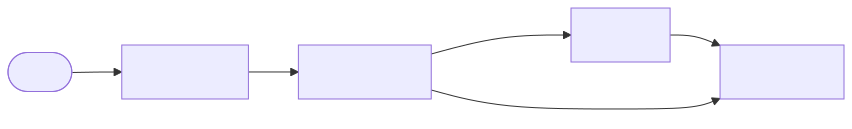

In [16]:
import base64
import requests
from IPython.display import SVG, display

def show_mermaid(code: str):
    graphbytes = code.encode("utf8")
    base64_string = base64.urlsafe_b64encode(graphbytes).decode("ascii")
    url = f"https://mermaid.ink/svg/{base64_string}"

    headers = {"User-Agent": "Mozilla/5.0"}
    resp = requests.get(url, headers=headers, timeout=15)

    if resp.status_code != 200:
        print(f"Failed ({resp.status_code}): {resp.text[:300]}")
        return None

    display(SVG(data=resp.content))

def graph_to_mermaid(builder_or_graph, direction: str = "LR") -> str:
    """Introspect a Strands GraphBuilder/Graph and emit Mermaid flowchart syntax."""
    nodes = builder_or_graph.nodes  # dict[str, GraphNode]
    edges = builder_or_graph.edges  # set[GraphEdge]
    entry_points = builder_or_graph.entry_points  # set[GraphNode]
    entry_ids = {n.node_id for n in entry_points}

    lines = [f"flowchart {direction}"]

    for node_id in nodes:
        shape = f'(["{node_id}"])' if node_id in entry_ids else f'["{node_id}"]'
        lines.append(f'    {node_id}{shape}')

    for edge in edges:
        source = edge.from_node.node_id
        target = edge.to_node.node_id
        condition = edge.condition
        if condition is not None:
            label = getattr(condition, "__name__", "condition")
            lines.append(f'    {source} -->|{label}| {target}')
        else:
            lines.append(f'    {source} --> {target}')

    return "\n".join(lines)

mermaid_code = graph_to_mermaid(builder, direction="LR")
print(mermaid_code)  # sanity check the generated syntax first
show_mermaid(mermaid_code)

## Appendix - Additional Setup Instructions
### The configuration for OpenAIModel
In AWS Strands (the open-source multi-agent framework), the OpenAIModel wrapper is used to route agent reasoning away from AWS Bedrock and over to OpenAI or OpenAI-compatible gateways (like Ollama or Portkey). [1, 2, 3, 4, 5] 
The configuration for OpenAIModel is split into three main top-level initialization arguments: model_id, client_args, and params. [1, 6] 

#### 1. model_id (String)
The explicit identifier string for the model you want to target. [7] 

* Examples: "gpt-4o", "gpt-4o-mini", "o1-preview", or your custom local deployment model string like "qwen2.5:7b". [1, 8, 9]  

#### 2. client_args (Dictionary)
This dictionary passes parameters directly down to the underlying openai.OpenAI() client constructor. Any configuration accepted by the official OpenAI Python SDK client goes here: [3, 10, 11, 12] 
* api_key: Your provider authorization token (e.g., os.environ.get("OPENAI_API_KEY")).
* base_url: The API target endpoint url. Mandatory if routing to local setups or custom gateways (e.g., "http://localhost:11434/v1" for Ollama, or a Portkey Gateway URL).
* timeout: Maximum duration in seconds to wait for a network response from the API before failing.
* max_retries: The integer count of automatic connection retry loops if the provider returns a network glitch or a 5xx server error.
* default_headers: Custom HTTP tracking headers passed down with every request payload wrapper. [3, 9, 13, 14, 15]  

#### 3. params (Dictionary)
This handles generation variables passed straight to the Chat Completions endpoint array during an execution sweep: [16] 
* temperature: Sets the creativity or determinism threshold (usually bounded between 0.0 and 2.0).
* max_tokens: The hard boundary constraint on completion token length generation.
* top_p: Nucleus sampling cutoff threshold (percentage pool constraint).
* seed: Integer anchor to establish repeatable, deterministic text generation where supported.
* presence_penalty / frequency_penalty: Penalization values to force phrase variety or discourage repetition loop behaviors. [1, 17, 18, 19, 20] 

### Structural Blueprint
When assembling these configuration segments in your script, the object construction looks like this:
```python
from strands.models.openai import OpenAIModel

openai_model = OpenAIModel(
    # 1. Target ID
    model_id="gpt-4o", 
    
    # 2. Client Base Configurations
    client_args={
        "api_key": "sk-your-key-here",
        "base_url": "https://openai.com",
        "timeout": 30.0,
        "max_retries": 3
    },
    
    # 3. Request Execution Configurations
    params={
        "temperature": 0.3,
        "max_tokens": 1500,
        "seed": 42,
        "top_p": 0.95
    }
)
```

[1] [https://aws.amazon.com](https://aws.amazon.com/blogs/opensource/introducing-strands-agents-1-0-production-ready-multi-agent-orchestration-made-simple/)
[2] [https://www.shareuhack.com](https://www.shareuhack.com/en/posts/openai-agents-sdk-indie-maker-guide-2026)
[3] [https://docs.portkey.ai](https://docs.portkey.ai/docs/integrations/agents/strands)
[4] [https://www.youtube.com](https://www.youtube.com/watch?v=uiBPNQPORJw&t=224)
[5] [https://neo4j.com](https://neo4j.com/labs/genai-ecosystem/strands-agents-neo4j/)
[6] [https://mlflow.org](https://mlflow.org/docs/latest/genai/tracing/integrations/listing/strands/)
[7] [https://www.youtube.com](https://www.youtube.com/watch?v=Z6urONR1b2s&t=262)
[8] [https://deepeval.com](https://deepeval.com/integrations/frameworks/strands)
[9] [https://docs.portkey.ai](https://docs.portkey.ai/docs/integrations/agents/strands)
[10] [https://www.youtube.com](https://www.youtube.com/watch?v=NzZOm-kaO94)
[11] [https://docs.portkey.ai](https://docs.portkey.ai/docs/integrations/agents/strands)
[12] [https://strandsagents.com](https://strandsagents.com/docs/user-guide/concepts/model-providers/openai-responses/)
[13] [https://dev.to](https://dev.to/aws/ai-agents-dont-need-complex-workflows-build-one-in-python-in-10-minutes-2m5d)
[14] [https://docs.databricks.com](https://docs.databricks.com/aws/en/mlflow3/genai/tracing/integrations/strands)
[15] [https://docs.ag2.ai](https://docs.ag2.ai/latest/docs/user-guide/advanced-concepts/llm-configuration-deep-dive/)
[16] [https://ai.google.dev](https://ai.google.dev/gemini-api/docs/openai)
[17] [https://www.pluralsight.com](https://www.pluralsight.com/resources/blog/ai-and-data/integrate-genai-applications-openai)
[18] [https://doc.akka.io](https://doc.akka.io/sdk/model-provider-details.html)
[19] [https://docs.camel-ai.org](https://docs.camel-ai.org/reference/camel.configs.openai_config)
[20] [https://developers.openai.com](https://developers.openai.com/api/docs/guides/advanced-usage)

### AWS Strands vs Pydantic
It is entirely possible to do the same in AWS Strands (strands-agents). [1] 

Because Strands uses raw, standard dictionary properties rather than specialized object settings, you inject your generation parameters (temperature, seed, max_tokens) inside the params dictionary arguments when initializing your model provider class. [2] 

#### Setting Parameters in Strands
```python
from strands.models.openai import OpenAIModel
# Define your parameter overrides in a standard Python dictionary
ollama_params = {
    "temperature": 0.1,    # Forces strict, logical generation blocks
    "seed": 42,            # Fixed seed to maximize output reproducibility
    "max_tokens": 150,     # Places a hard boundary on generation length
    "top_p": 0.9           # Nucleus sampling boundary limit
}
# Mount them directly inside the model instance constructor
ollama_model = OpenAIModel(
    model_id="qwen2.5:7b",
    client_args={
        "base_url": "http://localhost:11434/v1",
        "api_key": "Ollama",
    },
    params=ollama_params   # ✨ Model-generation parameters map here
)
```
#### Quick Comparison
The core architectural differences between the two frameworks' settings include:

| Configuration Goal | Pydantic AI Syntax | AWS Strands Syntax |
|---|---|---|
| Argument Key | model_settings={...} | params={...} |
| Object Scope | Can be passed to the Agent constructor | Must be passed to the Model constructor |
| Typing Wrapper | Supports dictionary or ModelSettings() classes | Uses raw Python dict[str, Any] primitives |

[1] [https://dev.to](https://dev.to/aws/using-strands-agents-with-anthropic-20jn)
[2] [https://medium.com](https://medium.com/@manmeetskalra/mastering-the-strands-agent-a-complete-guide-to-every-initialization-parameter-300cc9e2d69a)
[3] [https://www.linkedin.com](https://www.linkedin.com/pulse/strands-vs-claude-agent-sdk-two-very-different-bets-what-luca-bianchi-kplvf)
